In [4]:

# CELL 1 — Mount Drive and define all paths
# This connects NB2 to everything NB1 produced.
# We load split_indices.npz and cifar10h-probs.npy from Drive

from google.colab import drive
drive.mount('/content/drive')

import os

# Root project path — must match exactly what you used in NB1
PROJECT         = '/content/drive/MyDrive/cifar10h_project'
DATA_DIR        = os.path.join(PROJECT, 'data')
CHECKPOINTS_DIR = os.path.join(PROJECT, 'checkpoints')
RESULTS_DIR     = os.path.join(PROJECT, 'results')
CIFAR10_DIR     = os.path.join(DATA_DIR, 'cifar10')

# Files produced by NB1 — we load these, never recompute them
CIFAR10H_PATH   = os.path.join(DATA_DIR, 'cifar10h-probs.npy')
SPLIT_PATH      = os.path.join(DATA_DIR, 'split_indices.npz')
ENTROPY_PATH    = os.path.join(DATA_DIR, 'entropies.npy')

# Verify the NB1 files actually exist before going further
print("Checking NB1 outputs exist on Drive...")
for name, path in [("CIFAR-10H soft labels", CIFAR10H_PATH),
                   ("Split indices",          SPLIT_PATH),
                   ("Entropy array",          ENTROPY_PATH)]:
    exists = os.path.exists(path)
    print(f"  {'OK' if exists else 'MISSING — run NB1 first!'} {name}")

print("\nDrive connected. Ready to load data.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Checking NB1 outputs exist on Drive...
  OK CIFAR-10H soft labels
  OK Split indices
  OK Entropy array

Drive connected. Ready to load data.


In [5]:

# CELL 2 — All imports

import numpy as np
import matplotlib.pyplot as plt
import copy
import time

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models


SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
# Makes CUDA operations deterministic (slightly slower but reproducible)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False


DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")
if DEVICE.type == 'cuda':
    print(f"GPU   : {torch.cuda.get_device_name(0)}")
else:
    print("WARNING: No GPU found. Training will be very slow.")
    print("Go to Runtime → Change runtime type → T4 GPU")

CLASS_NAMES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print("\nAll imports successful.")

Device: cuda
GPU   : Tesla T4

All imports successful.


In [6]:

# CELL 3 — Load everything NB1 produced


#  Load soft labels
soft_labels = np.load(CIFAR10H_PATH).astype(np.float32)
print(f"Soft labels loaded   : shape {soft_labels.shape}")

#  Load split indices
split_data      = np.load(SPLIT_PATH)
train_indices   = split_data['train_indices']
val_indices     = split_data['val_indices']
test_indices    = split_data['test_indices']
print(f"Split loaded         : train={len(train_indices)}, "
      f"val={len(val_indices)}, test={len(test_indices)}")

#  Load precomputed entropies
entropies = np.load(ENTROPY_PATH)
print(f"Entropies loaded     : shape {entropies.shape}")

# Quick sanity check on the split
total = len(train_indices) + len(val_indices) + len(test_indices)
print(f"\nTotal indices        : {total} (expected 10000)")
print(f"Any overlap          : "
      f"{len(set(train_indices) & set(val_indices) & set(test_indices)) > 0}")


Soft labels loaded   : shape (10000, 10)
Split loaded         : train=6000, val=2000, test=2000
Entropies loaded     : shape (10000,)

Total indices        : 10000 (expected 10000)
Any overlap          : False


In [7]:

# CELL 4 — Define image transforms
# Transforms are applied to every image.
#
# TRAINING transform includes augmentation:
#   RandomHorizontalFlip, RandomCrop (randomly crops a 32x32 patch after padding with 4 pixels on each side)

CIFAR10_MEAN = (0.4914, 0.4822, 0.4465) #subtracts mean, divides by std for each RGB channel, Neural networks train faster and more stably when inputs are centered around 0 with unit variance
CIFAR10_STD  = (0.2470, 0.2435, 0.2616)
# output = (input - mean) / std


# For training: first convert to tensor then augmentation + normalisation
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN,
                         CIFAR10_STD)
])


eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD)
])

print("Transforms defined.")
print(f"  Train transform : flip + crop + normalise")
print(f"  Eval transform  : normalise only")
print(f"  Mean            : {CIFAR10_MEAN}")
print(f"  Std             : {CIFAR10_STD}")

Transforms defined.
  Train transform : flip + crop + normalise
  Eval transform  : normalise only
  Mean            : (0.4914, 0.4822, 0.4465)
  Std             : (0.247, 0.2435, 0.2616)


In [8]:

# CELL 5 — Custom Dataset class for soft labels
# We write a custom Dataset that:
#   1. Takes a subset of CIFAR-10 test images (by index)
#   2. Returns each image paired with its soft label from CIFAR-10H
#   3. The Hard label and the original index


class CIFAR10HDataset(Dataset):

    def __init__(self, indices, soft_labels, transform=None):

        self.cifar10_test = torchvision.datasets.CIFAR10(
            root=CIFAR10_DIR,
            train=False,
            download=False,
            transform=None
        )
        self.indices     = indices
        self.soft_labels = soft_labels
        self.transform   = transform

    def __len__(self):

        return len(self.indices)

    def __getitem__(self, i):

        actual_idx = self.indices[i]


        pil_image, hard_label = self.cifar10_test[actual_idx]

        # Apply transform (ToTensor + normalise + maybe augment)
        if self.transform is not None:
            image = self.transform(pil_image)
        else:
            image = transforms.ToTensor()(pil_image)


        soft_label = torch.tensor(
            self.soft_labels[actual_idx],
            dtype=torch.float32
        )


        return image, soft_label, hard_label, actual_idx

print("Testing CIFAR10HDataset...")

test_dataset = CIFAR10HDataset(train_indices[:10], soft_labels, train_transform)
img, soft, hard, idx = test_dataset[0]

print(f"  Image shape      : {img.shape}      (expected: torch.Size([3, 32, 32]))")
print(f"  Soft label shape : {soft.shape}   (expected: torch.Size([10]))")
print(f"  Soft label sum   : {soft.sum():.4f}       (expected: 1.0000)")
print(f"  Hard label       : {hard} ({CLASS_NAMES[hard]})")
print(f"  Original index   : {idx}")
print("Dataset class works correctly.")

Testing CIFAR10HDataset...
  Image shape      : torch.Size([3, 32, 32])      (expected: torch.Size([3, 32, 32]))
  Soft label shape : torch.Size([10])   (expected: torch.Size([10]))
  Soft label sum   : 1.0000       (expected: 1.0000)
  Hard label       : 7 (horse)
  Original index   : 228
Dataset class works correctly.


In [9]:

# CELL 6 — Create DataLoaders

BATCH_SIZE = 128
# Training DataLoader — shuffled, with augmentation
train_dataset = CIFAR10HDataset(train_indices, soft_labels, train_transform)
train_loader  = DataLoader(
    train_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = True,
    num_workers = 2,
    pin_memory  = True
)

# Validation DataLoader — not shuffled, no augmentation
val_dataset = CIFAR10HDataset(val_indices, soft_labels, eval_transform)
val_loader  = DataLoader(
    val_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = False,
    num_workers = 2,
    pin_memory  = True
)

# Test DataLoader — not shuffled, no augmentation
test_dataset = CIFAR10HDataset(test_indices, soft_labels, eval_transform)
test_loader  = DataLoader(
    test_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = False,
    num_workers = 2,
    pin_memory  = True
)

print("DataLoaders created:")
print(f"  Train : {len(train_dataset):,} images → "
      f"{len(train_loader)} batches of {BATCH_SIZE}")
print(f"  Val   : {len(val_dataset):,} images → "
      f"{len(val_loader)} batches of {BATCH_SIZE}")
print(f"  Test  : {len(test_dataset):,} images → "
      f"{len(test_loader)} batches of {BATCH_SIZE}")

DataLoaders created:
  Train : 6,000 images → 47 batches of 128
  Val   : 2,000 images → 16 batches of 128
  Test  : 2,000 images → 16 batches of 128


In [10]:

# CELL 7 — Model architecture: ResNet-18 for CIFAR-10

# Standard ResNet-18 from torchvision is designed for
# 224×224 ImageNet images. Two things make it wrong for CIFAR:
#
#   PROBLEM 1: First conv is 7×7 with stride 2.
#     On a 32×32 image, this immediately halves spatial size
#     to 16×16 and loses detail. We replace it with a 3×3
#     conv with stride 1 — no size reduction at the start.
#     Small images can't afford to lose half their pixels immediately
#
#   PROBLEM 2: First maxpool after the conv.
#     This halves spatial size again (32→16 or 16→8).
#     We remove it entirely by replacing with Identity.
#     Without this, image would shrink too much too fast
#
#   After these two fixes, the spatial resolution is preserved
#   properly through the early layers.
#
# The final fully-connected layer outputs 10 logits.
# Softmax converts them to a probability distribution.


class ResNet18CIFAR(nn.Module):
    """
    ResNet-18 adapted for 32×32 CIFAR images.
    Outputs a 10-dimensional probability distribution via softmax.
    """

    def __init__(self, pretrained_imagenet=False):
        """
        pretrained_imagenet : if True, load ImageNet pretrained weights.
                              Used for one ablation experiment.
                              If False, random initialisation.
        """
        super(ResNet18CIFAR, self).__init__()


        if pretrained_imagenet:
            self.backbone = models.resnet18(
                weights=models.ResNet18_Weights.IMAGENET1K_V1 #Loads ResNet-18 weights that were trained on ImageNet's 1,000-class dataset
            )
            print("Loaded ImageNet pretrained weights.")
        else:
            self.backbone = models.resnet18(weights=None)
            print("Random initialisation (no pretrained weights).")

        #  FIX 1: Replace first conv
        # Original: Conv2d(3, 64, kernel_size=7, stride=2, padding=3)
        # Ours    : Conv2d(3, 64, kernel_size=3, stride=1, padding=1)
        # This keeps the spatial size at 32×32 through the first layer.
        self.backbone.conv1 = nn.Conv2d(
            in_channels  = 3,
            out_channels = 64,
            kernel_size  = 3,
            stride       = 1,
            padding      = 1,
            bias         = False   # bias=False because BatchNorm follows
        )

        #  FIX 2: Remove first maxpool
        # nn.Identity() is a no-op — it passes input through unchanged.
        # This effectively removes the maxpool without changing
        # any other part of the architecture.
        self.backbone.maxpool = nn.Identity()

        #  Replace final FC layer
        # Original ResNet-18 fc: Linear(512, 1000) for ImageNet
        # We replace with: Linear(512, 10) for CIFAR-10
        num_features = self.backbone.fc.in_features   # = 512
        self.backbone.fc = nn.Linear(num_features, 10)

    def forward(self, x):
        """
        Forward pass.
        Input  x : (batch_size, 3, 32, 32) — normalised images
        Output   : (batch_size, 10) — probability distribution

        We apply softmax at the END so outputs are probabilities.

        """
        logits = self.backbone(x)
        probs  = F.softmax(logits, dim=1)
        return probs



model = ResNet18CIFAR(pretrained_imagenet=False)
model = model.to(DEVICE)

#  Count parameters
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\nModel created on device : {DEVICE}")
print(f"Total parameters        : {total_params:,}")
print(f"Trainable parameters    : {trainable_params:,}")
print(f"Approx size             : {total_params * 4 / 1024**2:.1f} MB (float32)")

Random initialisation (no pretrained weights).

Model created on device : cuda
Total parameters        : 11,173,962
Trainable parameters    : 11,173,962
Approx size             : 42.6 MB (float32)


In [11]:

# CELL 8 — Loss functions

# We implement three losses:
#
#   1. KL Divergence (mandatory, primary) this is the baseline, it directly measures distribution matching
#      Measures how different q is from p.
#      KL(p||q) = sum( p * log(p/q) )
#
#   2. Jensen-Shannon Divergence (second standard loss) [creates a midpoint distribution then measure how far both p and q are from m, m is average of both p and q]
#      A symmetric, bounded version of KL. [unlike kl, which is asymmetric this JSD is symmetric]
#      JSD(p,q) = 0.5*KL(p||m) + 0.5*KL(q||m) where m = 0.5*(p+q)
#      Always in [0, log(2)].
#
#   3. Custom: KL + Entropy Error Penalty
#      KL captures distribution shape.
#      The entropy penalty adds: if true entropy is high but
#      predicted entropy is low, add an extra penalty.
#      loss = KL(p||q) + lambda * max(0, H(p) - H(q))^2
#      This forces the model to learn the level of disagreement,
#      not just the shape of the distribution.

EPSILON = 1e-10   # prevents log(0) blowing up to -inf

def kl_divergence_loss(p, q):
    """
    KL Divergence: KL(p || q)

    p : (batch, 10) — true human soft labels (ground truth)
    q : (batch, 10) — predicted probabilities from model
    Returns: scalar mean loss over the batch
    """

    q_clamped = torch.clamp(q, min=EPSILON)



    p_safe = torch.clamp(p, min=EPSILON)  # only for the log(p) term
    kl = (p * (torch.log(p_safe) - torch.log(q_clamped))).sum(dim=1)


    return kl.mean()


def jsd_loss(p, q):
    """
    Jensen-Shannon Divergence (normalised to [0, 1])

    Symmetric: JSD(p,q) == JSD(q,p)
    Bounded  : always between 0 and 1 (after normalising by log(2))

    p : (batch, 10) — true soft labels
    q : (batch, 10) — predicted probabilities
    Returns: scalar mean loss over the batch
    """

    m = 0.5 * (p + q)
    m_clamped = torch.clamp(m, min=EPSILON)
    p_clamped = torch.clamp(p, min=EPSILON)
    q_clamped = torch.clamp(q, min=EPSILON)

    # JSD = 0.5 * KL(p||m) + 0.5 * KL(q||m)
    kl_pm = (p * (torch.log(p_clamped) - torch.log(m_clamped))).sum(dim=1)
    kl_qm = (q * (torch.log(q_clamped) - torch.log(m_clamped))).sum(dim=1)
    jsd   = 0.5 * kl_pm + 0.5 * kl_qm


    jsd_normalised = jsd / torch.log(torch.tensor(2.0))

    return jsd_normalised.mean()


def entropy_of(probs):
    """
    Helper: compute Shannon entropy (in nats) for a batch of distributions.
    probs : (batch, 10)
    Returns: (batch,) entropy per image
    """
    p_clamped = torch.clamp(probs, min=EPSILON)
    return -(probs * torch.log(p_clamped)).sum(dim=1)


def custom_kl_entropy_loss(p, q, lam=0.5):
    """
    Custom loss: KL Divergence + Entropy Error Penalty
    Full loss = KL(p||q) + lambda * mean(penalty)
    p : (batch, 10) — true soft labels
    q : (batch, 10) — predicted probabilities
    Returns: scalar mean loss over the batch
    """

    kl = kl_divergence_loss(p, q)


    h_p = entropy_of(p)

    h_q = entropy_of(q)

    # Penalty: only fires when model is more confident than humans

    entropy_penalty = torch.clamp(h_p - h_q, min=0.0) ** 2

    # Combine
    loss = kl + lam * entropy_penalty.mean()
    return loss


#  Quick test: verify all losses work on a dummy batch
print("Testing loss functions on dummy batch...")
dummy_p = torch.softmax(torch.randn(4, 10), dim=1).to(DEVICE)
dummy_q = torch.softmax(torch.randn(4, 10), dim=1).to(DEVICE)

kl_val     = kl_divergence_loss(dummy_p, dummy_q)
jsd_val    = jsd_loss(dummy_p, dummy_q)
custom_val = custom_kl_entropy_loss(dummy_p, dummy_q)

print(f"  KL loss     : {kl_val.item():.4f}   (should be > 0)")
print(f"  JSD loss    : {jsd_val.item():.4f}   (should be in [0, 1])")
print(f"  Custom loss : {custom_val.item():.4f}   (should be >= KL loss)")
print("All loss functions working correctly.")

Testing loss functions on dummy batch...
  KL loss     : 0.5835   (should be > 0)
  JSD loss    : 0.1805   (should be in [0, 1])
  Custom loss : 0.6021   (should be >= KL loss)
All loss functions working correctly.


In [12]:

# CELL 9 — Train one epoch and evaluate one epoch
#
# evaluate:
#   Loops through all batches in a loader (val or test).
#   Forward pass only
#   Returns average loss for the epoch.
#   Also returns all predictions and true labels.


def train_one_epoch(model, loader, optimizer, loss_fn, device):

    model.train()   # puts model in training mode (enables dropout etc.)
    total_loss  = 0.0
    total_items = 0

    for images, soft_labels, hard_labels, indices in loader:
        images      = images.to(device)
        soft_labels = soft_labels.to(device)

        # ── Forward pass
        predictions = model(images)

        # ── Compute loss
        loss = loss_fn(soft_labels, predictions)

        # ── Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Accumulate loss (multiply by batch size to get sum)
        total_loss  += loss.item() * len(images)
        total_items += len(images)

    return total_loss / total_items


def evaluate(model, loader, loss_fn, device):

    model.eval()

    total_loss  = 0.0
    total_items = 0
    all_preds   = []
    all_soft    = []
    all_hard    = []
    all_indices = []


    with torch.no_grad():
        for images, soft_labels, hard_labels, indices in loader:
            images      = images.to(device)
            soft_labels = soft_labels.to(device)

            predictions = model(images)
            loss        = loss_fn(soft_labels, predictions)

            total_loss  += loss.item() * len(images)
            total_items += len(images)


            all_preds.append(predictions.cpu().numpy())
            all_soft.append(soft_labels.cpu().numpy())
            all_hard.append(hard_labels.numpy())
            all_indices.append(indices.numpy())

    avg_loss    = total_loss / total_items
    all_preds   = np.concatenate(all_preds,   axis=0)
    all_soft    = np.concatenate(all_soft,    axis=0)
    all_hard    = np.concatenate(all_hard,    axis=0)
    all_indices = np.concatenate(all_indices, axis=0)

    return avg_loss, all_preds, all_soft, all_hard, all_indices


print("Train and evaluate functions defined.")

Train and evaluate functions defined.


In [13]:

# CELL 10 — Full training loop
# Early stopping:
# Checkpoint saving:
# Learning rate schedule:



def train_model(model, train_loader, val_loader, loss_fn,
                loss_name, num_epochs=100, lr=1e-3,
                patience=15, checkpoint_name='model'):
    """
    Full training loop with early stopping and best-model saving.

    model           : ResNet18CIFAR instance (already on device)
    train_loader    : DataLoader for training split
    val_loader      : DataLoader for validation split
    loss_fn         : which loss function to use
    loss_name       : string name for logging ('kl', 'jsd', 'custom')
    num_epochs      : maximum number of epochs to train
    lr              : initial learning rate
    patience        : early stopping patience (epochs without improvement)
    checkpoint_name : filename prefix for saved checkpoint

    Returns:
        model        : model loaded with best weights seen during training
        history      : dict with train/val loss lists per epoch
    """

    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    # weight_decay=1e-4 is L2 regularisation — helps prevent overfitting

    # Learning rate scheduler: halves LR if no improvement for 5 epochs
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5
    )

    checkpoint_path = os.path.join(
        CHECKPOINTS_DIR, f'{checkpoint_name}_best.pth'
    )

    best_val_loss    = float('inf')   # best seen so far (lower = better)
    epochs_no_improve = 0             # counter for early stopping
    history = {'train_loss': [], 'val_loss': []}

    print(f"\n{'='*55}")
    print(f"Training with {loss_name} loss")
    print(f"Max epochs: {num_epochs} | Patience: {patience} | LR: {lr}")
    print(f"Checkpoint: {checkpoint_path}")
    print(f"{'='*55}")
    print(f"{'Epoch':>6} {'Train Loss':>12} {'Val Loss':>12} "
          f"{'Best?':>7} {'Time':>7}")
    print("-" * 55)

    for epoch in range(1, num_epochs + 1):
        t_start = time.time()

        #  Train for one epoch
        train_loss = train_one_epoch(
            model, train_loader, optimizer, loss_fn, DEVICE
        )

        #  Evaluate on validation set
        val_loss, _, _, _, _ = evaluate(
            model, val_loader, loss_fn, DEVICE
        )

        #  Learning rate schedule step
        scheduler.step(val_loss)

        #  Log history
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        elapsed = time.time() - t_start
        is_best = val_loss < best_val_loss

        print(f"{epoch:>6} {train_loss:>12.5f} {val_loss:>12.5f} "
              f"{'  YES' if is_best else '':>7} {elapsed:>5.1f}s")

        if is_best:
            best_val_loss    = val_loss
            epochs_no_improve = 0
            torch.save({
                'epoch'       : epoch,
                'model_state' : model.state_dict(),
                'val_loss'    : val_loss,
                'loss_name'   : loss_name,
                'optimizer'   : optimizer.state_dict(),
            }, checkpoint_path)
        else:
            epochs_no_improve += 1

        #  Early stopping
        if epochs_no_improve >= patience:
            print(f"\nEarly stopping at epoch {epoch}.")
            print(f"No improvement for {patience} consecutive epochs.")
            break

    print(f"\nLoading best weights (val_loss={best_val_loss:.5f})...")
    checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
    model.load_state_dict(checkpoint['model_state'])

    print(f"Training complete. Best val loss: {best_val_loss:.5f}")
    return model, history


print("train_model function defined.")

train_model function defined.


In [14]:
# CELL 11 — Pretrain on CIFAR-10 hard labels (50k images)

#  CIFAR-10 training set DataLoader
pretrain_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD)
])

pretrain_dataset = torchvision.datasets.CIFAR10(
    root=CIFAR10_DIR, train=True,
    download=False, transform=pretrain_transform
)
pretrain_loader = DataLoader(
    pretrain_dataset, batch_size=BATCH_SIZE,
    shuffle=True, num_workers=2, pin_memory=True
)

print(f"Pretrain dataset: {len(pretrain_dataset):,} images")

#  Pretraining loop
pretrain_model = ResNet18CIFAR(pretrained_imagenet=False).to(DEVICE)
ce_loss_fn     = nn.CrossEntropyLoss()
pretrain_optim = optim.SGD(pretrain_model.parameters(),
                            lr=0.1, momentum=0.9, weight_decay=5e-4)
pretrain_sched = optim.lr_scheduler.CosineAnnealingLR(
    pretrain_optim, T_max=100
)

PRETRAIN_EPOCHS = 100
pretrain_history = {'train_loss': [], 'val_acc': []}
pretrain_ckpt    = os.path.join(CHECKPOINTS_DIR, 'pretrain_best.pth')

best_acc = 0.0
print(f"\nPretraining for {PRETRAIN_EPOCHS} epochs on 50k CIFAR-10 hard labels...")
print(f"{'Epoch':>6} {'Train Loss':>12} {'Val Acc':>10} {'Best?':>7} {'Time':>7}")
print("-" * 50)

for epoch in range(1, PRETRAIN_EPOCHS + 1):
    t_start = time.time()

    pretrain_model.train()
    total_loss = 0.0
    for images, labels in pretrain_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        logits = pretrain_model.backbone(images)
        loss   = ce_loss_fn(logits, labels)
        pretrain_optim.zero_grad()
        loss.backward()
        pretrain_optim.step()
        total_loss += loss.item()
    avg_train_loss = total_loss / len(pretrain_loader)

    pretrain_model.eval()
    correct = 0
    with torch.no_grad():
        for images, labels in DataLoader(
            torchvision.datasets.CIFAR10(CIFAR10_DIR, train=False,
                                         download=False,
                                         transform=eval_transform),
            batch_size=256, num_workers=2
        ):
            logits = pretrain_model.backbone(images.to(DEVICE))
            preds  = logits.argmax(dim=1).cpu()
            correct += (preds == labels).sum().item()
    val_acc = correct / 10000

    pretrain_sched.step()
    pretrain_history['train_loss'].append(avg_train_loss)
    pretrain_history['val_acc'].append(val_acc)

    is_best = val_acc > best_acc
    if is_best:
        best_acc = val_acc
        torch.save(pretrain_model.state_dict(), pretrain_ckpt)

    elapsed = time.time() - t_start
    print(f"{epoch:>6} {avg_train_loss:>12.4f} {val_acc:>10.4f} "
          f"{'  YES' if is_best else '':>7} {elapsed:>5.1f}s")

print(f"\nPretraining done. Best validation accuracy: {best_acc:.4f}")
print(f"Pretrained weights saved to: {pretrain_ckpt}")

Pretrain dataset: 50,000 images
Random initialisation (no pretrained weights).

Pretraining for 100 epochs on 50k CIFAR-10 hard labels...
 Epoch   Train Loss    Val Acc   Best?    Time
--------------------------------------------------
     1       1.9799     0.4142     YES  48.2s
     2       1.4532     0.4863     YES  46.1s
     3       1.1709     0.5668     YES  51.5s
     4       0.9578     0.6704     YES  50.9s
     5       0.7870     0.6661          51.4s
     6       0.6607     0.7244     YES  51.4s
     7       0.5886     0.7597     YES  51.2s
     8       0.5457     0.7745     YES  52.1s
     9       0.5192     0.7878     YES  51.1s
    10       0.4885     0.7612          51.6s
    11       0.4785     0.8260     YES  51.2s
    12       0.4570     0.7565          51.1s
    13       0.4412     0.7570          51.5s
    14       0.4323     0.7975          51.3s
    15       0.4188     0.7877          52.1s
    16       0.4109     0.8127          51.1s
    17       0.3975     0.77

In [15]:
# CELL 12 — Fine-tune on CIFAR-10H soft labels
# We fine-tune the pretrained model THREE times:
#   Run 1: KL divergence loss
#   Run 2: JSD loss
#   Run 3: Custom KL+entropy loss


# Load the best pretrained weights
pretrain_model.load_state_dict(
    torch.load(pretrain_ckpt, map_location=DEVICE)
)
print("Loaded pretrained weights as starting point for fine-tuning.\n")


all_histories = {}

#  Fine-tune configuration

FINETUNE_LR     = 1e-4
FINETUNE_EPOCHS = 100
PATIENCE        = 15

loss_configs = [
    (kl_divergence_loss,             'kl',     'kl'),
    (jsd_loss,                       'jsd',    'jsd'),
    (custom_kl_entropy_loss,         'custom', 'custom'),
]

for loss_fn, loss_name, ckpt_name in loss_configs:

    print(f"# Starting fine-tune run: {loss_name.upper()} loss")


    # Start from a fresh copy of pretrained weights each time
    run_model = copy.deepcopy(pretrain_model)
    run_model = run_model.to(DEVICE)

    trained_model, history = train_model(
        model           = run_model,
        train_loader    = train_loader,
        val_loader      = val_loader,
        loss_fn         = loss_fn,
        loss_name       = loss_name,
        num_epochs      = FINETUNE_EPOCHS,
        lr              = FINETUNE_LR,
        patience        = PATIENCE,
        checkpoint_name = ckpt_name
    )

    all_histories[loss_name] = history
    print(f"Checkpoint saved: {ckpt_name}_best.pth")


print("All three fine-tuning runs complete.")
print("Checkpoints saved to Drive:")
for _, _, ckpt_name in loss_configs:
    path = os.path.join(CHECKPOINTS_DIR, f'{ckpt_name}_best.pth')
    size = os.path.getsize(path) / 1024**2
    print(f"  {ckpt_name}_best.pth  ({size:.1f} MB)")

Loaded pretrained weights as starting point for fine-tuning.

# Starting fine-tune run: KL loss

Training with kl loss
Max epochs: 100 | Patience: 15 | LR: 0.0001
Checkpoint: /content/drive/MyDrive/cifar10h_project/checkpoints/kl_best.pth
 Epoch   Train Loss     Val Loss   Best?    Time
-------------------------------------------------------
     1      0.25921      0.19229     YES   6.7s
     2      0.14639      0.17501     YES   6.6s
     3      0.11920      0.17721           6.6s
     4      0.10385      0.17943           7.3s
     5      0.09468      0.18563           7.0s
     6      0.08582      0.18107           7.2s
     7      0.07848      0.18152           6.6s
     8      0.07161      0.17792           6.9s
     9      0.06821      0.17400     YES   6.6s
    10      0.06166      0.16925     YES   6.9s
    11      0.06028      0.16855     YES   6.5s
    12      0.05828      0.16623     YES   7.2s
    13      0.05784      0.17288           6.6s
    14      0.05491      0.16833

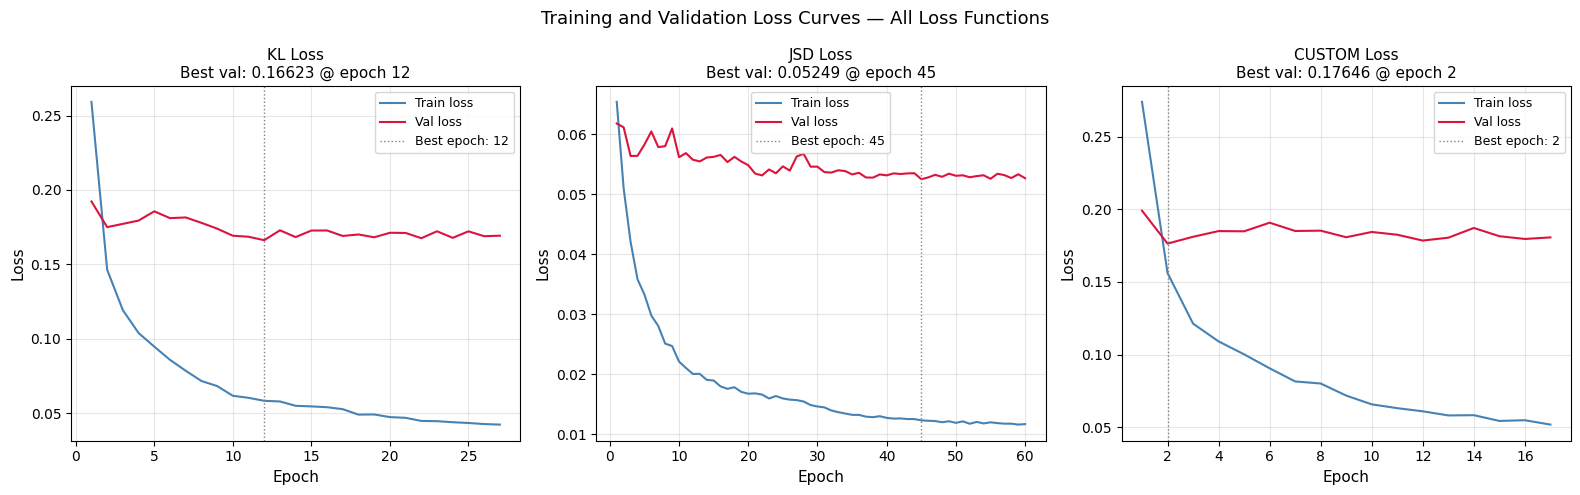

Saved to: /content/drive/MyDrive/cifar10h_project/results/training_curves.png


In [16]:
# CELL 13 — Training curves
# Required visualization: training and validation loss curves.
# convergence speed and final loss values across losses.

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Training and Validation Loss Curves — All Loss Functions',
             fontsize=13)

colors = {'train': 'steelblue', 'val': 'crimson'}

for ax, (loss_name, history) in zip(axes, all_histories.items()):
    epochs = range(1, len(history['train_loss']) + 1)

    ax.plot(epochs, history['train_loss'],
            color=colors['train'], linewidth=1.5, label='Train loss')
    ax.plot(epochs, history['val_loss'],
            color=colors['val'],   linewidth=1.5, label='Val loss')

    # Mark the best val loss point
    best_epoch = np.argmin(history['val_loss']) + 1
    best_val   = min(history['val_loss'])
    ax.axvline(x=best_epoch, color='gray', linestyle=':', linewidth=1,
               label=f'Best epoch: {best_epoch}')

    ax.set_title(f'{loss_name.upper()} Loss\n'
                 f'Best val: {best_val:.5f} @ epoch {best_epoch}',
                 fontsize=11)
    ax.set_xlabel('Epoch', fontsize=11)
    ax.set_ylabel('Loss', fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
save_path = os.path.join(RESULTS_DIR, 'training_curves.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved to: {save_path}")

In [17]:
# CELL 14 — Final checklist

print("NB2 COMPLETE — FILE CHECKLIST")

files_to_check = {
    "Pretrain checkpoint"      : os.path.join(CHECKPOINTS_DIR, 'pretrain_best.pth'),
    "KL fine-tune checkpoint"  : os.path.join(CHECKPOINTS_DIR, 'kl_best.pth'),
    "JSD fine-tune checkpoint" : os.path.join(CHECKPOINTS_DIR, 'jsd_best.pth'),
    "Custom fine-tune ckpt"    : os.path.join(CHECKPOINTS_DIR, 'custom_best.pth'),
    "Training curves plot"     : os.path.join(RESULTS_DIR,     'training_curves.png'),
}

all_ok = True
for name, path in files_to_check.items():
    exists = os.path.exists(path)
    size   = f"({os.path.getsize(path)/1024**2:.1f} MB)" if exists else ""
    print(f"  {'OK' if exists else 'MISSING':<8} {name:<30} {size}")
    if not exists:
        all_ok = False


if all_ok:
    print("All files present. NB2 complete.")
else:
    print("Some files missing — rerun the relevant cells.")


NB2 COMPLETE — FILE CHECKLIST
  OK       Pretrain checkpoint            (42.7 MB)
  OK       KL fine-tune checkpoint        (128.0 MB)
  OK       JSD fine-tune checkpoint       (128.0 MB)
  OK       Custom fine-tune ckpt          (128.0 MB)
  OK       Training curves plot           (0.1 MB)
All files present. NB2 complete.
